# Part 3 of the Project! SQL database containing all CSVs


#### Before we can build our database out, we need to have a defined relationship diagram that shows how are various tables and information will be related. I am going to lay out an ERD (Entity Relationship Diagram) to illustrate how the tables relate to one another, and what values go in what table.

![Tornado ERD](../Assets/Tornado_ERD.jpeg)

##### As you can see, we have a "main" table which our primary table concerning tornado data. We also have a supplemental table, the FEMA declarations table to have support our theory. Lastly, we have a third table to help bridge the connection between the two tables. This is our lookup table and contains geographical information


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sqlite3
import geopandas as ge
import seaborn as sns
from matplotlib.patches import Patch

os.makedirs('../Data/Tornado_SQL_database', exist_ok=True)
print(os.path.exists('../Data/Tornado_SQL_database'))

# Connect to (or create) the database using the conn variable 
conn = sqlite3.connect('../Data/Tornado_SQL_database/tornado_alley.db') # The cursor command lets us run commands to the connection crated above. You can't run SQL directly on the connection, hence the use of cursor.
cursor = conn.cursor()

# Creating tables // cursor.executescript() is the cursor performing the command to create multiple SQL statements at once.
cursor.executescript(""" 
    CREATE TABLE IF NOT EXISTS state_regions (
        state                  TEXT PRIMARY KEY,
        region_name            TEXT NOT NULL,
        is_eastern_shift_state INTEGER NOT NULL DEFAULT 0
    );

    CREATE TABLE IF NOT EXISTS fema_declarations (
        disaster_number  INTEGER PRIMARY KEY,
        state            TEXT NOT NULL,
        year             INTEGER NOT NULL,
        declaration_type TEXT NOT NULL,
        ia_declared      INTEGER NOT NULL DEFAULT 0,
        ih_declared      INTEGER NOT NULL DEFAULT 0,
        incident_type    TEXT NOT NULL
    );

    CREATE TABLE IF NOT EXISTS tornado_events (
        event_id          INTEGER PRIMARY KEY,
        state             TEXT NOT NULL,
        tor_f_scale       TEXT,
        tor_length        REAL,
        tor_width         REAL,
        fatalities        INTEGER NOT NULL,
        injuries          INTEGER NOT NULL,
        year              INTEGER NOT NULL
    );
""")

conn.commit() # SQL does not saves changes until they are commited.
print("Tables created successfully.")

True
Tables created successfully.


In [8]:
# Load cleaned data from CSVs
tornado_df = pd.read_csv('../Data/Cleaned_Tornado_Data/tornado_all_years_cleaned.csv')
FEMA_df = pd.read_csv('../Data/Cleaned_FEMA_Data/FEMA_data_cleaned.csv')
state_regions_df = pd.read_csv('../Data/Cleaned_Tornado_Data/eastern_state_notation.csv')

# Connect to database
conn = sqlite3.connect('../Data/Tornado_SQL_database/tornado_alley.db')

# Load into SQL tables
state_regions_df.to_sql('state_regions', conn, if_exists='replace', index=False)
tornado_df.to_sql('tornado_events', conn, if_exists='replace', index=False)
FEMA_df.to_sql('fema_declarations', conn, if_exists='replace', index=False)

conn.commit()
print("Data loaded successfully.")

Data loaded successfully.


In [9]:
pd.read_sql("""
    SELECT t.year, s.region_name, COUNT(*) as tornado_count
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    GROUP BY t.year, s.region_name
    ORDER BY t.year
""", conn)

,year,region_name,tornado_count
0,2004,Emerging,617
1,2004,Other,550
2,2004,Traditional,780
3,2014,Emerging,412
4,2014,Other,265
5,2014,Traditional,387
6,2024,Emerging,911
7,2024,Other,412
8,2024,Traditional,806


In [10]:
pd.read_sql("""
    SELECT t.year, s.region_name, 
           AVG(t.tor_length) as avg_length,
           AVG(t.tor_width) as avg_width
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    GROUP BY t.year, s.region_name
    ORDER BY t.year
""", conn)

,year,region_name,avg_length,avg_width
0,2004,Emerging,2.865478,103.320097
1,2004,Other,3.044727,78.249636
2,2004,Traditional,1.760641,109.903846
3,2014,Emerging,3.681262,211.228155
4,2014,Other,2.064000,116.766038
5,2014,Traditional,2.664160,181.961240
6,2024,Emerging,4.008332,244.196487
7,2024,Other,3.700097,156.611650
8,2024,Traditional,3.400918,205.435484


In [11]:
pd.read_sql("""
    SELECT f.year, s.region_name, COUNT(*) as declaration_count
    FROM fema_declarations f
    JOIN state_regions s ON f.state = s.state
    GROUP BY f.year, s.region_name
    ORDER BY f.year
""", conn)

,year,region_name,declaration_count
0,2004,Emerging,442
1,2004,Other,428
2,2004,Traditional,216
3,2014,Emerging,104
4,2014,Other,51
5,2014,Traditional,83
6,2024,Emerging,109
7,2024,Other,195
8,2024,Traditional,240


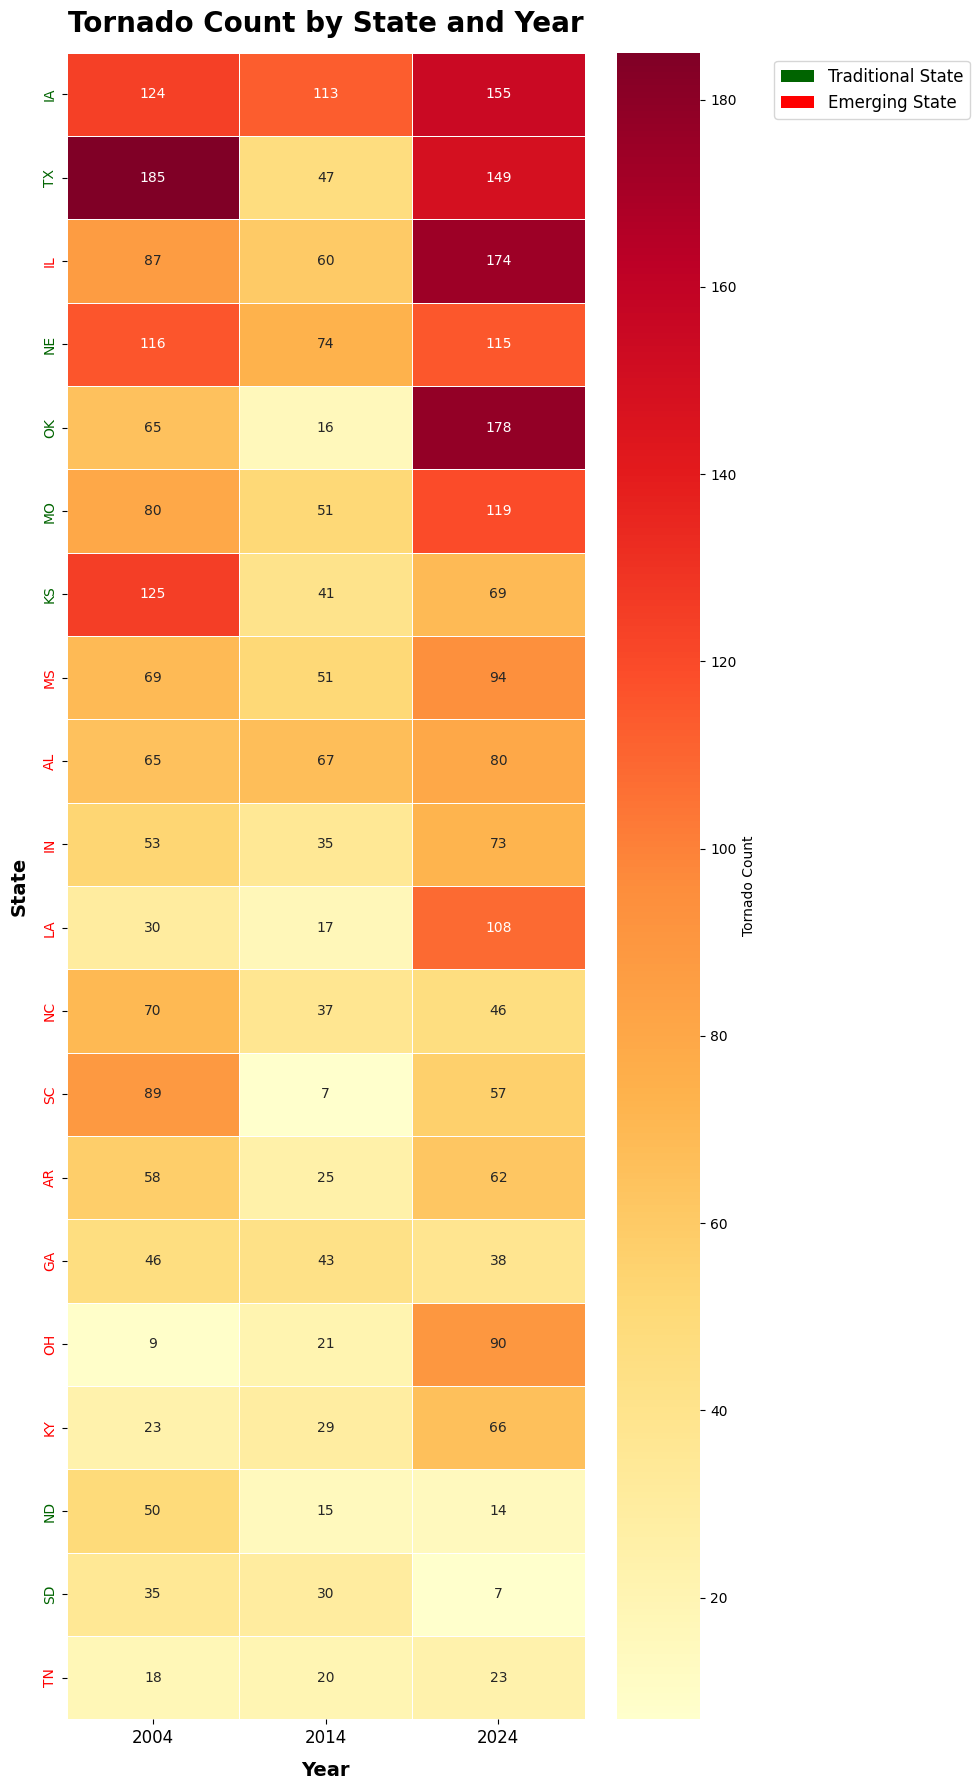

In [12]:
# Query tornado count by state and year
heatmap_df = pd.read_sql("""
    SELECT t.state, t.year, COUNT(*) as tornado_count
    FROM tornado_events t
    JOIN state_regions s ON t.state = s.state
    WHERE s.region_name IN ('Traditional', 'Emerging')
    GROUP BY t.state, t.year
    ORDER BY t.year
""", conn)

# Pivot for heatmap format
heatmap_pivot = heatmap_df.pivot(index='state', columns='year', values='tornado_count').fillna(0)

# Sort by total tornado count so most active states are at the top
heatmap_pivot = heatmap_pivot.loc[heatmap_pivot.sum(axis=1).sort_values(ascending=False).index]

# Create region lookup
region_lookup = pd.read_sql("SELECT state, region_name FROM state_regions", conn)
region_dict = dict(zip(region_lookup['state'], region_lookup['region_name']))

fig, ax = plt.subplots(figsize=(10, 18))
sns.heatmap(
    heatmap_pivot,
    cmap='YlOrRd',
    linewidths=0.5,
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'Tornado Count'},
    ax=ax
)

# Color y-axis labels by region
for label in ax.get_yticklabels():
    state = label.get_text()
    if region_dict.get(state) == 'Traditional':
        label.set_color('darkgreen')
    elif region_dict.get(state) == 'Emerging':
        label.set_color('red')

# Legend
legend_elements = [Patch(facecolor='darkgreen', label='Traditional State'),
                   Patch(facecolor='red', label='Emerging State')]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.35, 1), loc='upper left', fontsize=12)

ax.set_title('Tornado Count by State and Year', fontsize=20, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('State', fontsize=14, fontweight='bold', labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()